# An Apple a Day Keeps Prison Away
## Analyzing State-Level Patterns in Children's Social Program Investment and Criminal Justice Outcomes

**Author:** Alissa McKinney | 
**Course:** D502 Data Analytics Capstone | 
**Date:** June 2026

---

## <b>Project Overview</b>
This notebook contains the full analysis pipeline for examining the relationship between per capita investment in children's social programs and criminal justice outcomes across the United States from 2001 to 2016.

## <b>Table of Contents</b>

**Section 1** | Import Libraries  
**Section 2** | Load Data  
**Section 3** | Data Cleaning & Preparation  
**Section 4** | Merge Datasets  
**Section 5** | Feature Engineering & Scaling  
**Section 6** | K-Means Clustering  
**Section 7** | PCA & Visualization  
**Section 8** | Summary, Conclusion, & Next Steps

---

## <b>Section 1 | Import Libraries</b>

In [1]:
# Standard data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Display settings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

---

## <b>Section 2 | Load Data</b>

In [2]:
# Load the three primary datasets
spending = pd.read_excel('data/spending_on_kids.xlsx', sheet_name=None)
crime = pd.read_excel('data/ucr_by_state.xlsx')
prison = pd.read_excel('data/prison_custody_by_state.xlsx')

# Load only the relevant per-child spending sheets
snap = spending['SNAP_realperch']
medicaid = spending['Medicaid_CHIP_realperch']
headstart = spending['HeadStartPriv_realperch']

# Preview the SNAP sheet to understand the structure
print("SNAP Per Child Spending (Shape):", snap.shape)
print("\nFirst Few Rows:")
snap.head()

SNAP Per Child Spending (Shape): (51, 21)

First Few Rows:


,state,1997,1998,1999,2000,2001,2002,2003,2004,2005,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Alabama,240.596054,218.586945,213.115738,203.516434,213.891022,230.767517,254.145798,285.732727,319.919952,...,296.957489,319.458130,449.909119,538.611084,621.204407,558.121033,532.685852,511.367798,521.417786,478.407288
1,Alaska,206.495972,180.114960,174.770386,162.898346,164.730865,198.835770,219.768478,209.476593,251.702225,...,236.425507,264.925293,330.570282,406.708893,436.130035,427.537292,431.333405,400.435699,381.219696,381.960449
2,Arizona,197.318619,151.021408,130.676468,131.980865,148.285339,196.489365,233.382462,264.849396,259.135529,...,245.056549,278.813568,412.749146,501.830933,495.446472,508.979553,498.718842,435.871643,417.632568,385.272247
3,Arkansas,202.318832,195.450775,203.081100,187.350143,208.180618,236.172455,269.463409,289.774414,327.570801,...,303.049072,311.277313,399.322845,456.739777,470.019897,470.583649,461.313507,414.656769,386.635895,360.218079
4,California,220.366180,198.422333,166.192108,153.336929,144.799881,152.920822,157.928787,166.270111,187.736908,...,191.351471,215.300003,295.153931,390.407715,412.722931,431.658203,450.673798,419.833344,421.059143,383.915741


In [3]:
# Preview crime data structure
print("Crime Data (Shape):", crime.shape)
print("\nCrime Columns:", crime.columns.tolist())
print("\n First Few Rows:")
crime.head()

Crime Data (Shape): (869, 15)

Crime Columns: ['jurisdiction', 'year', 'crime_reporting_change', 'crimes_estimated', 'state_population', 'violent_crime_total', 'murder_manslaughter', 'rape_legacy', 'rape_revised', 'robbery', 'agg_assault', 'property_crime_total', 'burglary', 'larceny', 'vehicle_theft']

 First Few Rows:


,jurisdiction,year,crime_reporting_change,crimes_estimated,state_population,violent_crime_total,murder_manslaughter,rape_legacy,rape_revised,robbery,agg_assault,property_crime_total,burglary,larceny,vehicle_theft
0,Alaska,2001,0,0,633630,3735,39,501.0,NaN,514,2681,23160,3847,16695,2618
1,Alaska,2002,0,0,641482,3627,33,511.0,NaN,489,2594,24118,3908,17739,2471
2,Alaska,2003,0,0,648280,3877,39,605.0,NaN,446,2787,24386,3874,18051,2461
3,Alaska,2004,0,0,657755,4159,37,558.0,NaN,447,3117,22172,3773,16159,2240
4,Alaska,2005,0,0,663253,4194,32,538.0,NaN,537,3087,23975,4131,17249,2595


In [4]:
# Preview prison data structure
print("Prison Data (Shape):", prison.shape)
print("\nPrison Columns:", prison.columns.tolist())
print("\nFirst Few Rows:")
prison.head()

Prison Data (Shape): (51, 18)

Prison Columns: ['jurisdiction', 'includes_jails', 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]

First Few Rows:


,jurisdiction,includes_jails,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Federal,0,149852,158216,168144,177600,186364,190844,197285,198414,205087,206968,214774,216915,214989,209561,195622,188311
1,Alabama,0,24741,25100,27614,25635,24315,24103,25253,25363,27241,27345,26813,26768,26825,26145,25212,23745
2,Alaska,1,4570,4351,4472,4534,4798,5052,5151,4997,5472,5369,6216,6308,5081,6323,5247,4378
3,Arizona,0,27710,29359,31084,32384,33345,35752,37700,39455,40544,40130,39949,40013,41031,42136,42204,42248
4,Arkansas,0,11489,11849,12068,12577,12455,12854,13275,13135,13338,14192,14090,14043,14295,15250,15784,15833


---

## <b>Section 3 | Data Cleaning & Preparation</b>

This section addresses the preparation of three primary datasets for analysis. Key steps include reshaping data from wide to long format, standardizing jurisdiction names, filtering to the 50-state study window (2001-2016), and resolving data quality issues identified during exploration.

### 3.1 Reshaping Spending Data (Wide to Long)
The spending datasets were provided in wide format with `years` as columns. The `melt` function was used to convert each sheet to long format for merging.

In [5]:
# Define a function to melt wide datasets
def melt_spending(df, value_name):
    """
    Converts a wide-format spending sheet to long format.
    Keeps only years 2001-2016 to match our study window.
    """
    
    # Melt wide to long
    melted = pd.melt(
    df,
    id_vars=['state'],  # Create primary column
    value_vars=[str(year) for year in range(2001,2017)],  # Retains only relevant years
    var_name='year',  # Name column that holds relevant years
    value_name=value_name  # Name the column to hold the dollar amount
    )

    # Convert year to integer
    melted['year'] = melted['year'].astype(int)
    return melted

# Apply new function to each spending sheets
snap_long = melt_spending(snap, 'snap_per_child')
medicaid_long = melt_spending(medicaid, 'medicaid_per_child')
headstart_long = melt_spending(headstart, 'headstart_per_child')

# Preview results
print("SNAP Long Format Shape:", snap_long.shape)
print("\nFirst Few Rows:")
snap_long.head()

SNAP Long Format Shape: (816, 3)

First Few Rows:


,state,year,snap_per_child
0,Alabama,2001,213.891022
1,Alaska,2001,164.730865
2,Arizona,2001,148.285339
3,Arkansas,2001,208.180618
4,California,2001,144.799881


In [6]:
# Melt prison data with two primary columns
prison_long = pd.melt(
    prison,
    id_vars=['jurisdiction', 'includes_jails'],  # Create primary columns
    value_vars=[year for year in range(2001,2017)],  # Retains only relevant years
    var_name='year',  # Name column that holds relevant years
    value_name='prisoner_count'  # Name the column to hold prisoner count
)

# Convert year to integer
prison_long['year'] = prison_long['year'].astype(int)

# Preview results
print("Prison Long Format Shape:", prison_long.shape)
print("\nFirst Few Rows:")
prison_long.head()

Prison Long Format Shape: (816, 4)

First Few Rows:


,jurisdiction,includes_jails,year,prisoner_count
0,Federal,0,2001,149852
1,Alabama,0,2001,24741
2,Alaska,1,2001,4570
3,Arizona,0,2001,27710
4,Arkansas,0,2001,11489


### 3.2 Filter Jurisdictions

### 3.2.1 Discovery - Jurisdiction Data Quality Issues in Crime Dataset
Initial exploration of the raw crime dataset revealed two data quality issues:
- **Leading/trailing whitespace** — causing duplicate jurisdictions <i>(e.g., `'Alabama'` and `'     Alabama'`)</i>
- **Non-state jurisdictions** — DC (labeled as both 'DC' and 'District of Columbia'), Puerto Rico, Federal, and United States Total

These were resolved by applying `str.strip()` before filtering.

In [7]:
# Load raw crime data to demonstrate pre-cleaning jurisdiction issues
crime_raw = pd.read_excel('data/ucr_by_state.xlsx')
print("Raw Jurisdictions Before Cleaning & Filtering:\n")
print(sorted(crime_raw['jurisdiction'].unique()))
print("\nTotal Unique:", crime_raw['jurisdiction'].nunique())
del crime_raw  # Remove from memory after demonstration

Raw Jurisdictions Before Cleaning & Filtering:

['     Alabama', '     Alaska', '     Arizona', '     Arkansas', '     California', '     Colorado', '     Connecticut', '     Delaware', '     District of Columbia', '     Florida', '     Georgia', '     Hawaii', '     Idaho', '     Illinois', '     Indiana', '     Iowa', '     Kansas', '     Kentucky', '     Louisiana', '     Maine', '     Maryland', '     Massachusetts', '     Michigan', '     Minnesota', '     Mississippi', '     Missouri', '     Montana', '     Nebraska', '     Nevada', '     New Hampshire', '     New Jersey', '     New Mexico', '     New York', '     North Carolina', '     North Dakota', '     Ohio', '     Oklahoma', '     Oregon', '     Pennsylvania', '     Rhode Island', '     South Carolina', '     South Dakota', '     Tennessee', '     Texas', '     Utah', '     Vermont', '     Virginia', '     Washington', '     West Virginia', '     Wisconsin', '     Wyoming', 'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'Calif

### 3.2.2 Fix No. 1 - Removing Whitespace
Leading and trailing whitespace was removed from the `jurisdiction` column in the crime dataset using `str.strip()`. This resolves the duplicate jurisdiction issue identified in 3.2.1.

In [8]:
# Strip whitespace from crime jurisdiction names
crime['jurisdiction'] = crime['jurisdiction'].str.strip()

# Confirm whitespace removed and unique values reduced to 50
print("Unique Jurisdictions After Filtering & Removing Whitespace:\n")
print(sorted(crime['jurisdiction'].unique()))
print("\nTotal Unique:", crime['jurisdiction'].nunique())

Unique Jurisdictions After Filtering & Removing Whitespace:

['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'DC', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

Total Unique: 53


### 3.2.3 Fix No. 2 - Filtering Non-State Jurisdictions
Following whitespace removal, 53 unique jurisdictions remain in the Crime dataset. In this section, the three non-state jurisdictions (Federal, District of Columbia/DC, and Puerto Rico) are excluded from all five datasets using a predefined exclusion list.

In [9]:
# Define non-state jurisdiction exclusion list
exclude = ['District of Columbia', 'DC', 'Federal', 'Puerto Rico', 'United States Total']

# Apply exclusion filter to each of the datasets
prison_long = prison_long[~prison_long['jurisdiction'].isin(exclude)]
snap_long = snap_long[~snap_long['state'].isin(exclude)]
medicaid_long = medicaid_long[~medicaid_long['state'].isin(exclude)]
headstart_long = headstart_long[~headstart_long['state'].isin(exclude)]
crime = crime[~crime['jurisdiction'].isin(exclude)]

# Verify all datasets now contain exactly 50 states
print("Row Counts After Filtering:")
print("  SNAP:", len(snap_long))
print("  Medicaid:", len(medicaid_long))
print("  Head Start:", len(headstart_long))
print("  Crime:", len(crime))
print("  Prison:", len(prison_long))

# Verify jurisdictions counts
print("\nUnique Jurisdictions After Filtering:")
print(f"  Prison: {prison_long['jurisdiction'].nunique()}")
print(f"  Crime: {crime['jurisdiction'].nunique()}")
print(f"  SNAP States: {snap_long['state'].nunique()}")

Row Counts After Filtering:
  SNAP: 800
  Medicaid: 800
  Head Start: 800
  Crime: 849
  Prison: 800

Unique Jurisdictions After Filtering:
  Prison: 50
  Crime: 50
  SNAP States: 50


### 3.2.4 Fix No. 3 - Filter Year Range of Crime Dataset
The crime dataset included data through 2017, which exceeded the study window of 2001-2016. The dataset was filtered to retain only years within the agreed-upon study window.

In [10]:
# Check how many 2017 rows exist before filtering
print("Rows With Year > 2016 Before Filter:", 
      len(crime[crime['year'] > 2016]))

# Apply crime dataset year range filter
crime = crime[crime['year'] <= 2016]

# Verify post-filtering year range == 2001-2016
print("\nCrime Year Range After Filtering:")
print(f"  Min Year: {crime['year'].min()}")
print(f"  Max Year: {crime['year'].max()}")
print(f"  Total Rows: {len(crime)}")

Rows With Year > 2016 Before Filter: 50

Crime Year Range After Filtering:
  Min Year: 2001
  Max Year: 2016
  Total Rows: 799


### 3.2.5 Verification: All Datasets Clean
After completing all cleaning steps, a final verification confirms that all 5 datasets contain exactly 50 states across the 2001-2016 study window, except for the Crime dataset, which contains 799 rows due to the known New York 2015 value addressed in Section 3.3.

In [11]:
# Final record count verification of all cleaned datasets
print("Final Row Counts:")
print(f"  SNAP:       {len(snap_long)} rows")
print(f"  Medicaid:   {len(medicaid_long)} rows")
print(f"  Head Start: {len(headstart_long)} rows")
print(f"  Prison:     {len(prison_long)} rows")
print(f"  Crime:      {len(crime)} rows")

# Final year range verification of all cleaned datasets
print("\nYear Ranges:")
print(f"  Crime: {crime['year'].min()} to {crime['year'].max()}")
print(f"  Prison: {prison_long['year'].min()} to {prison_long['year'].max()}")
print(f"  SNAP: {snap_long['year'].min()} to {snap_long['year'].max()}")

Final Row Counts:
  SNAP:       800 rows
  Medicaid:   800 rows
  Head Start: 800 rows
  Prison:     800 rows
  Crime:      799 rows

Year Ranges:
  Crime: 2001 to 2016
  Prison: 2001 to 2016
  SNAP: 2001 to 2016


### 3.3 Impute Missing Values
The final verification in Section 3.2.5 revealed one missing state/year combination in the crime dataset: New York 2015. The missing value was identified using an itertools cross-reference of all expected state/year combinations. The value was imputed as the average of the New York 2014 and 2016 values and flagged as estimated to maintain transparency.

### 3.3.1 Identify Missing State/Year Combination(s)

In [12]:
# Import itertools to allow for cross-reference identification
from itertools import product

# Create a complete set of all expected state/year combinations
all_states = sorted(crime['jurisdiction'].unique())
all_years = list(range(2001, 2017))
expected = set(product(all_states, all_years))

# Create a set of what we actually have
actual = set(zip(crime['jurisdiction'], crime['year']))

# Determine missing values by subtracting actual set from expected set
missing = expected - actual
print("Missing State/Year Combination(s):")
for state, year in sorted(missing):
    print(f"  {state} - {year}")  # Print missing value results

Missing State/Year Combination(s):
  New York - 2015


### 3.3.2 Calculate Imputed Values for New York 2015

In [13]:
# Define 2014 and 2016 values for NY 
ny_2014 = crime[(crime['jurisdiction'] == 'New York') & 
                (crime['year'] == 2014)]['violent_crime_total'].values[0]
ny_2016 = crime[(crime['jurisdiction'] == 'New York') & 
                (crime['year'] == 2016)]['violent_crime_total'].values[0]

# Calculate average using new variables
ny_2015_est = (ny_2014 + ny_2016) / 2

# Print 2014, 2015, & 2016 values for NY
print(f"New York 2014: {ny_2014}")
print(f"New York 2016: {ny_2016}")
print(f"Imputed 2015 Value: {ny_2015_est}")

New York 2014: 75398
New York 2016: 74315
Imputed 2015 Value: 74856.5


### 3.3.3 Insert Imputed New York 2015 Row

In [14]:
# Create the missing New York 2015 row
ny_2015_row = crime[
    (crime['jurisdiction'] == 'New York') & 
    (crime['year'] == 2014)
].copy()

# Update the year and violent crime total
ny_2015_row['year'] = 2015
ny_2015_row['violent_crime_total'] = ny_2015_est
ny_2015_row['crimes_estimated'] = True  # Flag as estimated

# Append to crime dataframe and sort
crime = pd.concat([crime, ny_2015_row], ignore_index=True)
crime = crime.sort_values(['jurisdiction', 'year']).reset_index(drop=True)

# Print row count and tail of NY data to verify imputation successful
print("Crime Rows:", len(crime))
print("\nNew York Rows:")
crime[crime['jurisdiction'] == 'New York'][['jurisdiction', 'year', 'violent_crime_total']].tail(5)

Crime Rows: 800

New York Rows:


,jurisdiction,year,violent_crime_total
507,New York,2012,79535.0
508,New York,2013,77563.0
509,New York,2014,75398.0
510,New York,2015,74856.5
511,New York,2016,74315.0


### Section 3 Summary
All five datasets are now clean and ready for merging:
- 800 rows each across 50 states and 16 years (2001–2016).
- Jurisdiction names standardized and non-state entries removed.
- Crime dataset imputed for New York 2015 and flagged as estimated.

---

## <b>Section 4 | Merge Datasets</b>
The five cleaned datasets are merged into a single analytical dataframe using state and year as the join keys. An inner join is used to ensure only complete records across all datasets are retained.

### 4.1 Merge Spending Datasets

In [15]:
# Merge SNAP and Medicaid on state and year
spending_merged = pd.merge(
    snap_long,
    medicaid_long,
    on=['state', 'year'],
    how='inner'
)

# Merge Head Start to the new SNAP/Medicaid table
spending_merged = pd.merge(
    spending_merged,
    headstart_long,
    on=['state', 'year'],
    how='inner'
)

# Print shape and head of merged spending dataset
print("Spending Merged Shape:", spending_merged.shape)
print("\nFirst Few Rows:")
spending_merged.head()

Spending Merged Shape: (800, 5)

First Few Rows:


,state,year,snap_per_child,medicaid_per_child,headstart_per_child
0,Alabama,2001,213.891022,672.874573,92.452484
1,Alaska,2001,164.730865,1680.456055,77.948792
2,Arizona,2001,148.285339,1015.753723,62.841885
3,Arkansas,2001,208.180618,1201.147583,93.963669
4,California,2001,144.799881,879.696228,70.795929


### 4.2 Merge Crime & Prison Datasets in 'Outcomes' Dataset

In [16]:
# Rename jurisdiction to state for consistency
crime_renamed = crime.rename(columns={'jurisdiction': 'state'})
prison_renamed = prison_long.rename(columns={'jurisdiction': 'state'})

# Merge crime and prison on state and year
outcomes_merged = pd.merge(
    crime_renamed[['state', 'year', 'violent_crime_total', 
                   'state_population', 'crimes_estimated']],
    prison_renamed[['state', 'year', 'prisoner_count']],
    on=['state', 'year'],
    how='inner'
)

# Print shape and head of merged crime/prison 'outcome' dataset
print("Outcomes Merged Shape:", outcomes_merged.shape)
print("\nFirst Few Rows:")
outcomes_merged.head()

Outcomes Merged Shape: (800, 6)

First Few Rows:


,state,year,violent_crime_total,state_population,crimes_estimated,prisoner_count
0,Alabama,2001,19582.0,4468912,0,24741
1,Alabama,2002,19931.0,4478896,0,25100
2,Alabama,2003,19331.0,4503726,0,27614
3,Alabama,2004,19324.0,4525375,0,25635
4,Alabama,2005,19678.0,4548327,0,24315


### 4.3 Merging Spending & Outcomes into Single Dataframe

In [17]:
# Merge spending and outcome datasets on state/year using inner join
df = pd.merge(
    spending_merged,
    outcomes_merged,
    on=['state', 'year'],
    how='inner'
)

print("Master Dataframe Shape:", df.shape)  # Print shape of master dataframe
print("\nColumns:", df.columns.tolist())  # Print column names in master dataframe
print("\nFirst few rows:")  
df.head()  # Print first 5 rows of master dataframe for QA/QC

Master Dataframe Shape: (800, 9)

Columns: ['state', 'year', 'snap_per_child', 'medicaid_per_child', 'headstart_per_child', 'violent_crime_total', 'state_population', 'crimes_estimated', 'prisoner_count']

First few rows:


,state,year,snap_per_child,medicaid_per_child,headstart_per_child,violent_crime_total,state_population,crimes_estimated,prisoner_count
0,Alabama,2001,213.891022,672.874573,92.452484,19582.0,4468912,0,24741
1,Alaska,2001,164.730865,1680.456055,77.948792,3735.0,633630,0,4570
2,Arizona,2001,148.285339,1015.753723,62.841885,28675.0,5306966,0,27710
3,Arkansas,2001,208.180618,1201.147583,93.963669,12190.0,2694698,0,11489
4,California,2001,144.799881,879.696228,70.795929,212867.0,34600463,0,157142


### 4.4 Calculating Per Capita Crime & Incarceration Rates

In [18]:
# Calculate violent crime rate per 100K persons at the state-level pop
df['violent_crime_rate'] = (
    df['violent_crime_total'] / df['state_population'] * 100000
)

# Calculate incarceration rate per 100K persons at the state-level pop
df['incarceration_rate'] = (
    df['prisoner_count'] / df['state_population'] * 100000
)

# Add new per capita crime/prison rates to df
print("New Columns Added:\n")
print(df[['state', 'year', 'violent_crime_rate', 
          'incarceration_rate']].head(10))

New Columns Added:

         state  year  violent_crime_rate  incarceration_rate
0      Alabama  2001          438.182717          553.624685
1       Alaska  2001          589.460726          721.241103
2      Arizona  2001          540.327562          522.143914
3     Arkansas  2001          452.369802          426.355755
4   California  2001          615.214311          454.161553
5     Colorado  2001          349.628492          389.935520
6  Connecticut  2001          334.594809          509.724271
7     Delaware  2001          611.097930          858.775871
8      Florida  2001          798.328746          442.206930
9      Georgia  2001          495.748290          546.499705


### 4.5 Final Master Dataframe Verification

In [19]:
# Print summary stats inc. shape, state count, year range, and column count
print("Master Dataframe Summary:")
print(f"  Shape: {df.shape}")
print(f"  States: {df['state'].nunique()}")
print(f"  Years: {df['year'].min()} to {df['year'].max()}")
print(f"  Columns: {len(df.columns)}")

# Verify null/missing value counts = 0 for all 11 columns
print("\nMissing Values Per Column:")
print(df.isnull().sum())

# Verify data types appropriate for all 11 columns
print("\nData Types:")
print(df.dtypes)

Master Dataframe Summary:
  Shape: (800, 11)
  States: 50
  Years: 2001 to 2016
  Columns: 11

Missing Values Per Column:
state                  0
year                   0
snap_per_child         0
medicaid_per_child     0
headstart_per_child    0
violent_crime_total    0
state_population       0
crimes_estimated       0
prisoner_count         0
violent_crime_rate     0
incarceration_rate     0
dtype: int64

Data Types:
state                      str
year                     int64
snap_per_child         float64
medicaid_per_child     float64
headstart_per_child    float64
violent_crime_total    float64
state_population         int64
crimes_estimated         int64
prisoner_count           int64
violent_crime_rate     float64
incarceration_rate     float64
dtype: object


### Section 4 Summary
All five cleaned datasets have been successfully merged into a single master dataframe containing 800 records across 50 states and 16 years (2001-2016). Per capita rates for violent crime and incarceration have been calculated per 100,000 state residents to allow for fair comparison across states of varying sizes. The master data frame contains zero missing values and is ready for feature engineering and clustering.

## <b>Section 5 | Feature Engineering & Scaling</b>
The master dataframe is aggregated to state-level averages across the 2001-2016 study window. Five features are selected for clustering: three investment variables (SNAP, Medicaid, and Head Start Per-Child Spending) and two outcome variables (Violent Crime Rate and Incarceration Rate Per 100K Population). Features are then scaled using StandardScaler to ensure K-Means is not biased by magnitude differences between variables.

### 5.1 Aggregate to State-Level Averages

In [20]:
# Define the list of investment and outcome variables (features)
features = ['snap_per_child', 'medicaid_per_child', 'headstart_per_child',
            'violent_crime_rate', 'incarceration_rate']

# Create new dataframe using investment/outcome features
df_state = df.groupby('state')[features].mean().reset_index()

# Print shape and first 5 rows of new dataframe
print("State-Level Dataframe Shape:", df_state.shape)
print("\nFirst Few Rows:")
df_state.head()

State-Level Dataframe Shape: (50, 6)

First Few Rows:


,state,snap_per_child,medicaid_per_child,headstart_per_child,violent_crime_rate,incarceration_rate
0,Alabama,401.967164,1470.084129,91.766065,441.628213,550.454449
1,Alaska,311.816107,2552.610878,70.001772,644.441898,740.242855
2,Arizona,345.723557,1996.843655,54.416044,471.897096,591.726438
3,Arkansas,354.877454,2256.179512,102.151246,497.353998,472.389881
4,California,287.698406,1533.224339,65.373484,488.950962,417.625501


### 5.2 Scale Features Using StandardScaler

In [21]:
# Instantiate scaler
scaler = StandardScaler()

# Scale only the feature columns, preserve state names
df_scaled = df_state.copy()
df_scaled[features] = scaler.fit_transform(df_state[features])

# Print summary statistics for newly scaled dataset
print("Scaled Feature Statistics:")
print(df_scaled[features].describe().round(3))

Scaled Feature Statistics:
       snap_per_child  medicaid_per_child  headstart_per_child  \
count          50.000              50.000               50.000   
mean           -0.000              -0.000               -0.000   
std             1.010               1.010                1.010   
min            -1.794              -1.549               -1.260   
25%            -0.826              -0.688               -0.708   
50%             0.255              -0.260               -0.155   
75%             0.631               0.532                0.529   
max             2.338               3.510                5.046   

       violent_crime_rate  incarceration_rate  
count              50.000              50.000  
mean               -0.000               0.000  
std                 1.010               1.010  
min                -1.760              -1.715  
25%                -0.813              -0.619  
50%                -0.271               0.001  
75%                 0.685               0.

## <b>Section 6 | K-Means Clustering</b>
The optimal number of clusters is determined using the Elbow Method, which plots inertia across a range of k values. The silhouette score is then calculated to validate the cluster quality. K-Means is applied to the scaled state-level data to identify natural groupings.

### 6.1 Using the Elbow Method to Determine Optimal K
Inertia measures how tightly packed clusters are. Lower is better, but more clusters always reduce inertia, so the 'elbow' is used to determine where adding clusters stops providing meaningful improvement.

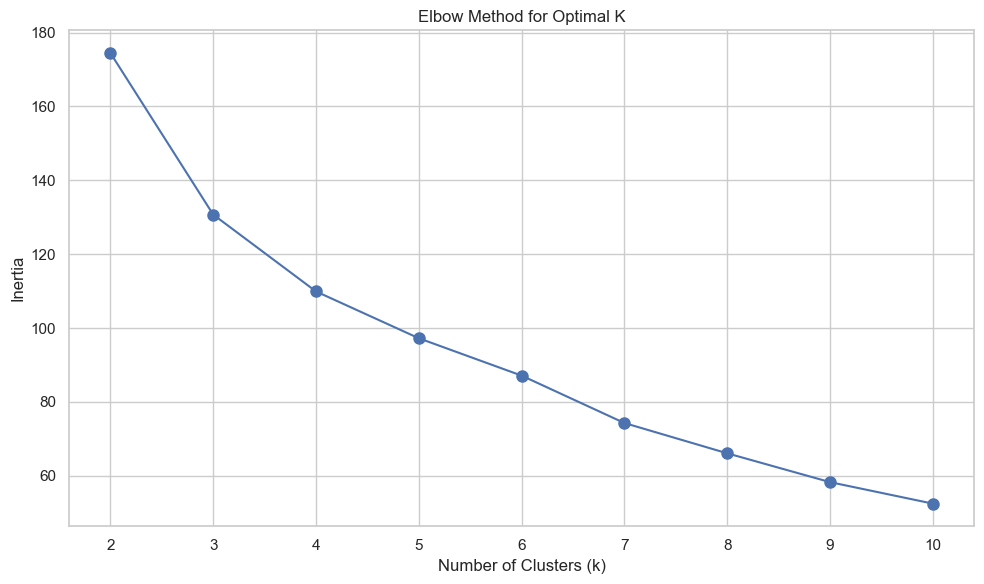

Inertia Values:
  k=2: 174.49
  k=3: 130.73
  k=4: 109.91
  k=5: 97.23
  k=6: 87.12
  k=7: 74.28
  k=8: 66.08
  k=9: 58.27
  k=10: 52.45


In [22]:
# Set X to scaled feature values from section 5.2
X = df_scaled[features].values

# Create an empty interia list and define cluster range to test against
inertia = []
k_range = range(2, 11)

# Iterate thru for loop to test each cluster size; append results to inertia list
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('visualizations/elbow_curve.png', dpi=150)
plt.show()

# Print summary df of inertia value at each K
print("Inertia Values:")
for k, i in zip(k_range, inertia):
    print(f"  k={k}: {i:.2f}")

### 6.2 Silhouette Scores for `K=4` & `K=5`
The Silhouette Score can range from -1 to 1. Values above 0.3 indicate acceptable clustering, and values exceeding 0.5 indicate strong clustering.

In [23]:
from sklearn.metrics import silhouette_score

# Create for loop to iterate thru K=4 & K=5; print results
for k in [4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}: Silhouette Score = {score:.4f}")

k=4: Silhouette Score = 0.3058
k=5: Silhouette Score = 0.2616


### 6.3 Final Fit K-Means Model with `K=4`

In [24]:
# Define kmeans with 4 clusters per silhouette score results
# Random_state=42 for repoducibility
# N_init=10 runs K-Means 10 different times, returns best result
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) 

# Fit and predict new kmeans variable on X
df_state['cluster'] = kmeans.fit_predict(X)

# Print final silhouette score and cluster membership count for K=4
print("Final K-Means Model - k=4")
print(f"Silhouette Score: {silhouette_score(X, df_state['cluster']):.4f}")
print("\nStates per Cluster:")
print(df_state['cluster'].value_counts().sort_index())

Final K-Means Model - k=4
Silhouette Score: 0.3058

States per Cluster:
cluster
0     9
1    21
2    19
3     1
Name: count, dtype: int64


In [25]:
# Identify member states for each cluster
print("States per Cluster:\n")
for cluster in range(4):
    states = df_state[df_state['cluster'] == cluster]['state'].tolist()
    print(f"Cluster {cluster} ({len(states)} states):")
    print(", ".join(sorted(states)))
    print()

States per Cluster:

Cluster 0 (9 states):
Arkansas, Kentucky, Maine, New Mexico, New York, Pennsylvania, Rhode Island, Vermont, West Virginia

Cluster 1 (21 states):
Colorado, Connecticut, Idaho, Indiana, Iowa, Kansas, Massachusetts, Minnesota, Montana, Nebraska, New Hampshire, New Jersey, North Dakota, Ohio, Oregon, South Dakota, Utah, Virginia, Washington, Wisconsin, Wyoming

Cluster 2 (19 states):
Alabama, Alaska, Arizona, California, Delaware, Florida, Georgia, Hawaii, Illinois, Louisiana, Maryland, Michigan, Missouri, Nevada, North Carolina, Oklahoma, South Carolina, Tennessee, Texas

Cluster 3 (1 states):
Mississippi



### 6.4 Cluster Profiling

In [26]:
# Profiling uses UNSCALED values for interpretability
# Scaled values are only used for the clustering algorithm itself

# Merge cluster assignments back to unscaled state data
df_state_profiles = df_state[['state', 'cluster']].merge(
    df.groupby('state')[features].mean().reset_index(),
    on='state'
)

# Calculate the mean of each feature per cluster
cluster_profiles = df_state_profiles.groupby('cluster')[features].mean()

# Print cluster average results for selected features
print("Cluster Profiles (Average Values Across 2001-2016):\n")
print(cluster_profiles.round(2))

Cluster Profiles (Average Values Across 2001-2016):

         snap_per_child  medicaid_per_child  headstart_per_child  \
cluster                                                            
0                334.66             2367.44                97.77   
1                221.28             1207.15                63.31   
2                342.34             1520.68                72.39   
3                422.20             1900.58               228.40   

         violent_crime_rate  incarceration_rate  
cluster                                          
0                    332.12              313.12  
1                    286.74              320.75  
2                    527.87              508.23  
3                    293.64              535.59  


### 6.5 ANOVA to Test Statistical Significance of Cluster Differences
While the relationship between investment and outcomes was not linear as originally hypothesized, four statistically distinct state clusters emerged (F-statistics ranging from `12.38` to `33.30`, all <i>p</i> < 0.0001), confirming that meaningful patterns exist in the data.

In [27]:
# Null hypothesis: No significant difference in feature means across clusters
# Alpha = 0.05; p-value < 0.05 rejects the null hypothesis

from scipy import stats

# Create a for loop to calculate the F-statistic, p-value, 
# and significance determination for selected features

print("ANOVA Results by Feature:\n")

for feature in features:
    # Get values for each cluster
    groups = [df_state_profiles[df_state_profiles['cluster'] == c][feature].values 
              for c in range(4)]
    
    # Run one-way ANOVA
    f_stat, p_value = stats.f_oneway(*groups)
    
    significance = "Significant" if p_value < 0.05 else "Not Significant"
    print(f"{feature}:")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  {significance}\n")

ANOVA Results by Feature:

snap_per_child:
  F-statistic: 18.6631
  P-value: 0.0000
  Significant

medicaid_per_child:
  F-statistic: 21.4179
  P-value: 0.0000
  Significant

headstart_per_child:
  F-statistic: 33.3011
  P-value: 0.0000
  Significant

violent_crime_rate:
  F-statistic: 17.8964
  P-value: 0.0000
  Significant

incarceration_rate:
  F-statistic: 12.3817
  P-value: 0.0000
  Significant



## <b>Section 7 | PCA & Visualization</b>
Principal Component Analysis (PCA) is applied to reduce the five-dimensional feature space to two dimensions for visualization. Cluster assignments are then communicated through a PCA scatter plot, choropleth map, bar charts, and box plots.

### 7.1 PCA for Cluster Visualization

In [28]:
# PCA reduces 5 dimensions to 2 for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Variance explained tells us how much of the story is captured
print("Variance Explained by Each Component:\n")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.2%}")

Variance Explained by Each Component:

  PC1: 44.39%
  PC2: 27.59%
  Total: 71.98%


### 7.2 PCA Scatter Plot

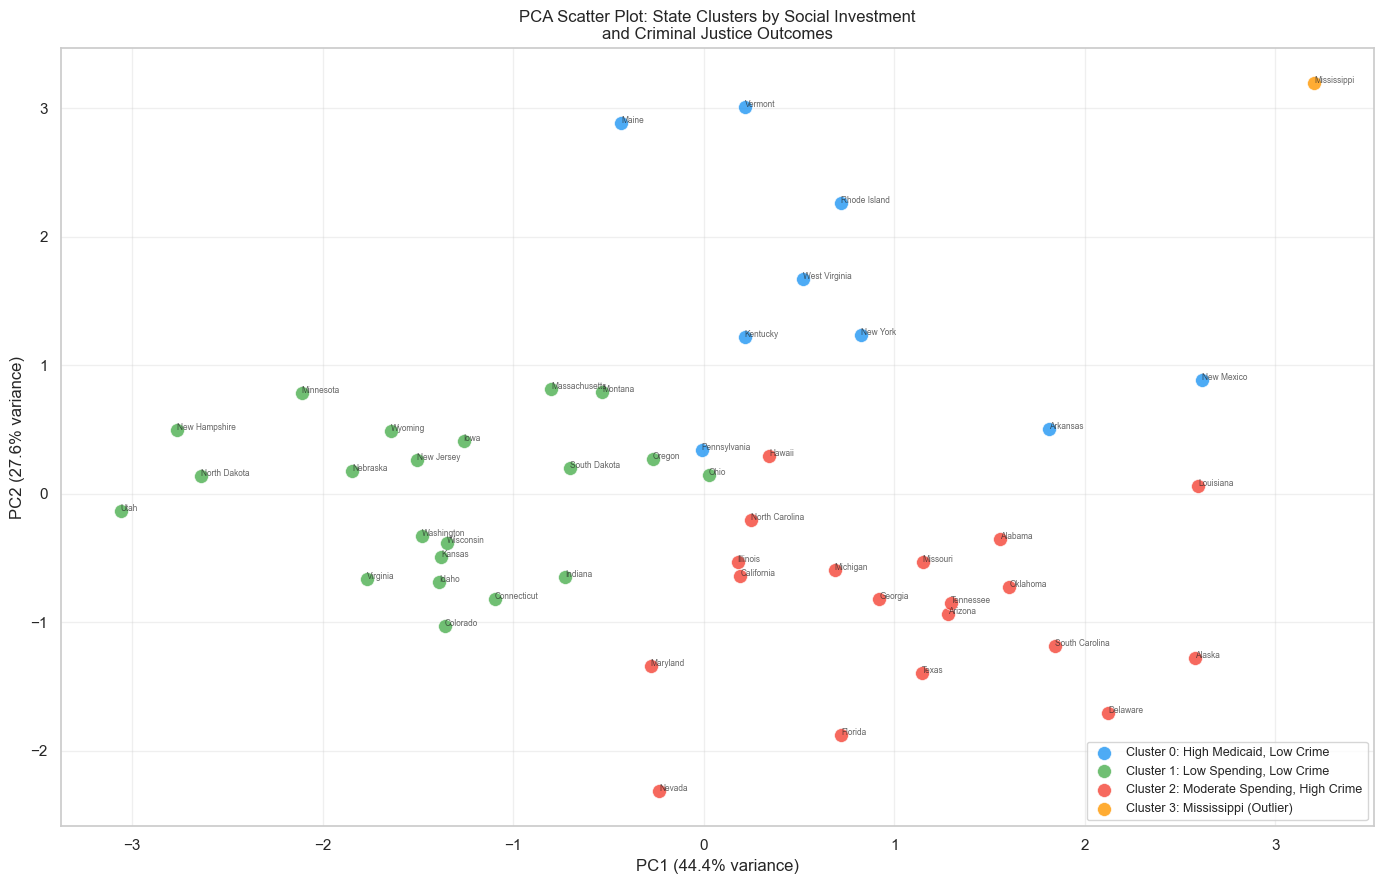

In [29]:
# Define cluster colors and labels
colors = ['#2196F3', '#4CAF50', '#F44336', '#FF9800']
cluster_names = {
    0: 'Cluster 0: High Medicaid, Low Crime',
    1: 'Cluster 1: Low Spending, Low Crime',
    2: 'Cluster 2: Moderate Spending, High Crime',
    3: 'Cluster 3: Mississippi (Outlier)'
}

fig, ax = plt.subplots(figsize=(14, 9))

for cluster in range(4):
    mask = df_state['cluster'] == cluster
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[cluster],
        label=cluster_names[cluster],
        s=100,
        alpha=0.8,
        edgecolors='white',
        linewidth=0.5
    )
    for idx in df_state[mask].index:
        ax.annotate(
            df_state.loc[idx, 'state'],
            (X_pca[idx, 0], X_pca[idx, 1]),
            fontsize=6,
            alpha=0.7
        )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA Scatter Plot: State Clusters by Social Investment\nand Criminal Justice Outcomes')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Cluster Comparison Bar Chart

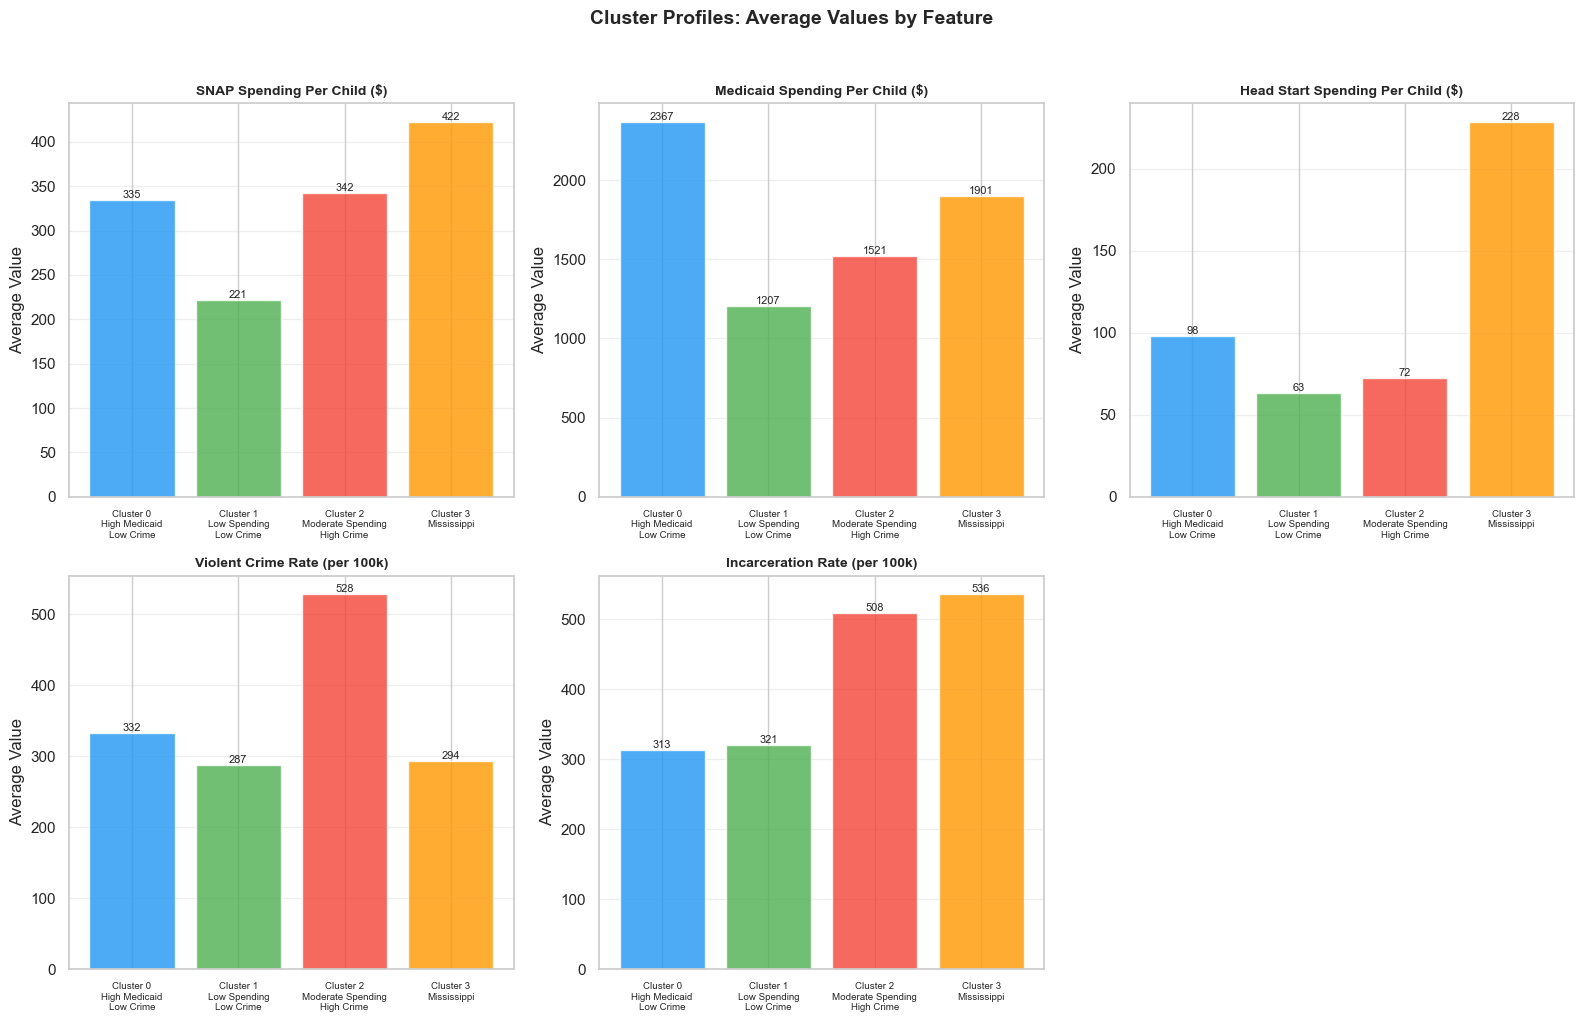

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Cluster Profiles: Average Values by Feature', 
             fontsize=14, fontweight='bold', y=1.02)

cluster_labels = ['Cluster 0\nHigh Medicaid\nLow Crime', 
                  'Cluster 1\nLow Spending\nLow Crime',
                  'Cluster 2\nModerate Spending\nHigh Crime', 
                  'Cluster 3\nMississippi']

feature_titles = {
    'snap_per_child': 'SNAP Spending Per Child ($)',
    'medicaid_per_child': 'Medicaid Spending Per Child ($)',
    'headstart_per_child': 'Head Start Spending Per Child ($)',
    'violent_crime_rate': 'Violent Crime Rate (per 100k)',
    'incarceration_rate': 'Incarceration Rate (per 100k)'
}

axes_flat = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes_flat[idx]
    values = cluster_profiles[feature].values
    bars = ax.bar(range(4), values, color=colors, alpha=0.8, edgecolor='white')
    ax.set_title(feature_titles[feature], fontsize=10, fontweight='bold')
    ax.set_xticks(range(4))
    ax.set_xticklabels(cluster_labels, fontsize=7)
    ax.set_ylabel('Average Value')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# Hide the empty 6th subplot
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.savefig('visualizations/bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Choropleth Map
*Note: The choropleth map is saved as an interactive HTML file at `visualizations/choropleth_map.html` and can be viewed in any browser.*

In [31]:
# Install plotly for interactive choropleth
import subprocess
subprocess.run(['pip', 'install', 'plotly', '--quiet'])

import plotly.express as px

# Create state to cluster mapping
map_data = df_state[['state', 'cluster']].copy()
map_data['cluster_name'] = map_data['cluster'].map({
    0: 'Cluster 0: High Medicaid, Low Crime',
    1: 'Cluster 1: Low Spending, Low Crime', 
    2: 'Cluster 2: Moderate Spending, High Crime',
    3: 'Cluster 3: Mississippi'
})

fig = px.choropleth(
    map_data,
    locations='state',
    locationmode='USA-states',
    color='cluster_name',
    scope='usa',
    title='State Clusters by Social Investment and Criminal Justice Outcomes',
    color_discrete_map={
        'Cluster 0: High Medicaid, Low Crime': '#2196F3',
        'Cluster 1: Low Spending, Low Crime': '#4CAF50',
        'Cluster 2: Moderate Spending, High Crime': '#F44336',
        'Cluster 3: Mississippi': '#FF9800'
    }
)

fig.update_layout(
    title_x=0.5,
    legend_title='Cluster',
    geo=dict(showlakes=True, lakecolor='lightblue')
)

fig.write_html('visualizations/choropleth_map.html')
fig.show()
print("Choropleth map successfully saved to visualizations/choropleth_map.html")

Choropleth map successfully saved to visualizations/choropleth_map.html


### 7.5 Box Plot of Distribution Within Clusters

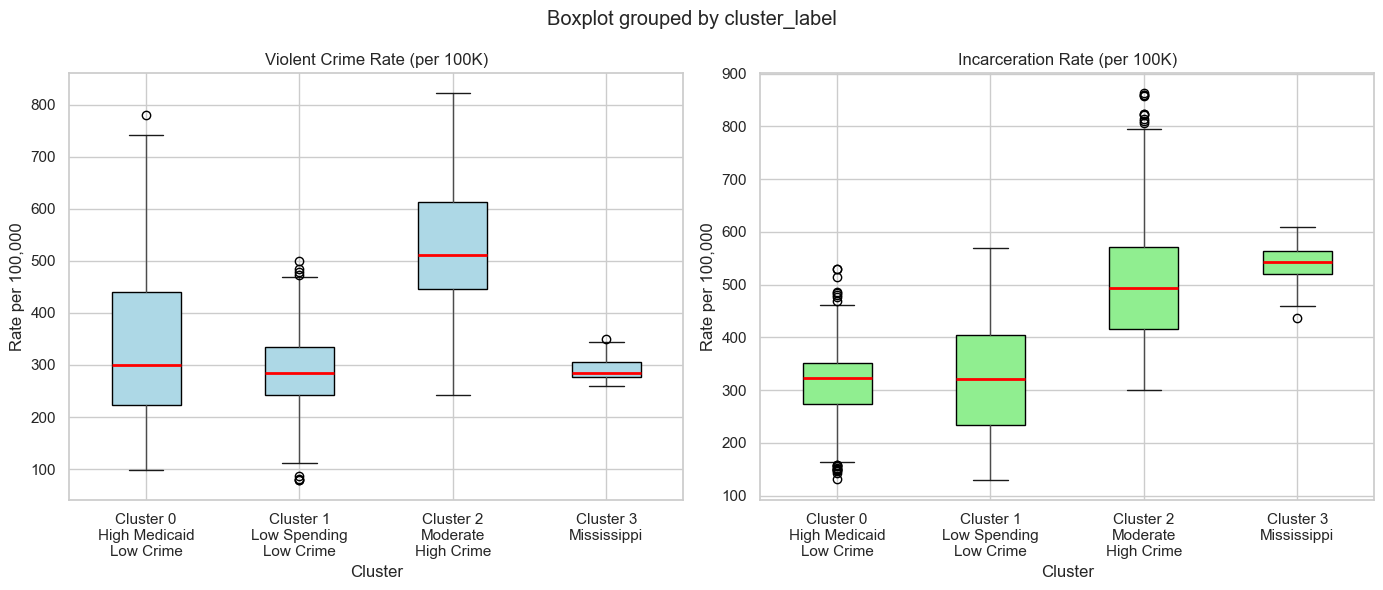

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution of Outcome Variables by Cluster', 
             fontsize=14, fontweight='bold')

# Merge cluster assignments back to the full dataset for box plots
df_plot = df.merge(df_state[['state', 'cluster']], on='state')
df_plot['cluster_label'] = df_plot['cluster'].map({
    0: 'Cluster 0\nHigh Medicaid\nLow Crime',
    1: 'Cluster 1\nLow Spending\nLow Crime',
    2: 'Cluster 2\nModerate\nHigh Crime',
    3: 'Cluster 3\nMississippi'
})

# Violent crime rate box plot
df_plot.boxplot(
    column='violent_crime_rate',
    by='cluster_label',
    ax=axes[0],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=2)
)
axes[0].set_title('Violent Crime Rate (per 100K)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Rate per 100,000')

# Incarceration rate box plot
df_plot.boxplot(
    column='incarceration_rate',
    by='cluster_label',
    ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_title('Incarceration Rate (per 100K)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Rate per 100,000')

plt.tight_layout()
plt.savefig('visualizations/box_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## <b>Section 8 | Summary, Conclusion, & Next Steps</b>

### 8.1 Research Question Revisited
This project asked: *Do states with higher per capita investment in children's social programs have lower rates of violent crime and incarceration?*

### 8.2 Key Findings
K-Means clustering identified four statistically distinct state clusters (ANOVA p < 0.001 for all features). The relationship between investment and outcomes was more complex than the original hypothesis anticipated:
- **Cluster 0** (9 states): High Medicaid investment, lowest violent crime (332/100K)
- **Cluster 1** (21 states): Lowest spending, but also low crime (287/100K)  
- **Cluster 2** (19 states): Moderate spending, highest crime (528/100K)
- **Cluster 3** (Mississippi): Extreme Head Start investment, low crime but high incarceration

### 8.3 Hypothesis Evaluation
The hypothesis that higher investment would be linearly associated with lower crime and incarceration rates was not directly supported. However, the analysis revealed that states with the HIGHEST crime and incarceration rates (Cluster 2) also had only MODERATE levels of investment. This suggests that insufficient investment may be associated with worse outcomes, even if higher investment alone does not guarantee better ones.

### 8.4 Limitations
- Silhouette score of 0.3058 indicates acceptable but not strong cluster separation
- PCA captures 71.98% of the variance, meaning 28% of the data story is not visible in 2D visualizations
- The analysis does not account for baseline socioeconomic need, which likely mediates the relationship between investment and outcomes
- Correlation does not imply causation

### 8.5 Recommendations
1. **Future research** should incorporate socioeconomic need indicators (poverty rates, median income, unemployment) alongside spending data to better understand the conditions under which investment is most effective.

2. **Policymakers** in Cluster 2 states should examine whether current investment levels are sufficient given their communities' needs, particularly in states with both high crime rates and moderate program spending.